# Импорты и загрузка данных

In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import random
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)

df = pd.read_csv('2008.csv')

df['FL_DATE'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + 
    df['Month'].astype(str).str.zfill(2) + '-' + 
    df['DayofMonth'].astype(str).str.zfill(2)
)

df = df.sort_values('FL_DATE').reset_index(drop=True)

# Приведение типов аэропортов
df['Origin'] = df['Origin'].astype(str)
df['Dest'] = df['Dest'].astype(str)

# Определение стартового аэропорта
START_AIRPORT = 'ABE' # Код аэропорта Allentown
all_airports = set(df['Origin']).union(set(df['Dest']))

if START_AIRPORT not in all_airports:
    print(f"'{START_AIRPORT}' не найден, берем первый попавшийся.")
    START_AIRPORT = df['Origin'].iloc[0]

total_airports = len(all_airports)
start_time_global = df['FL_DATE'].min()
end_time_global = df['FL_DATE'].max()

print(f"Всего аэропортов: {total_airports}")
print(f"️Всего рейсов: {len(df)}")
print(f"Старт: {START_AIRPORT}")
print(f"Период: {start_time_global.date()} — {end_time_global.date()}")

'ABE' не найден, берем первый попавшийся.
Всего аэропортов: 64
️Всего рейсов: 24216
Старт: IAD
Период: 2008-01-03 — 2008-01-10


# Функция симуляции SI-модели

In [14]:
def simulate_infection(df, start_airport, p):
    """
    Симулирует распространение инфекции.
    Возвращает dict: {время_заражения: [список_зараженных_аэропортов]}
    """
    infected = {start_airport}
    # Инициализируем словарь: ключ - время, значение - список аэропортов
    infection_log = {df['FL_DATE'].iloc[0]: [start_airport]}
    
    for row in df.itertuples():
        flight_time = row.FL_DATE
        origin = row.Origin
        dest = row.Dest
        
        # Инфекция передается: вылет из зараженного -> прилет в здорового
        if origin in infected and dest not in infected:
            if np.random.random() < p:
                infected.add(dest)
                
                # Если время уже есть в логе, добавляем в список
                if flight_time in infection_log:
                    infection_log[flight_time].append(dest)
                else:
                    infection_log[flight_time] = [dest]
                
    return infection_log

# Тестовый запуск
print("Запуск тестовой симуляции:")
test_log = simulate_infection(df, START_AIRPORT, p=0.5)
total_infected = sum(len(v) for v in test_log.values())
print(f"Заражено аэропортов: {total_infected}")

Запуск тестовой симуляции:
Заражено аэропортов: 64


# Влияние вероятности заражения на скорость

Симуляция для p=0.01
Симуляция для p=0.05
Симуляция для p=0.1
Симуляция для p=0.5
Симуляция для p=1.0


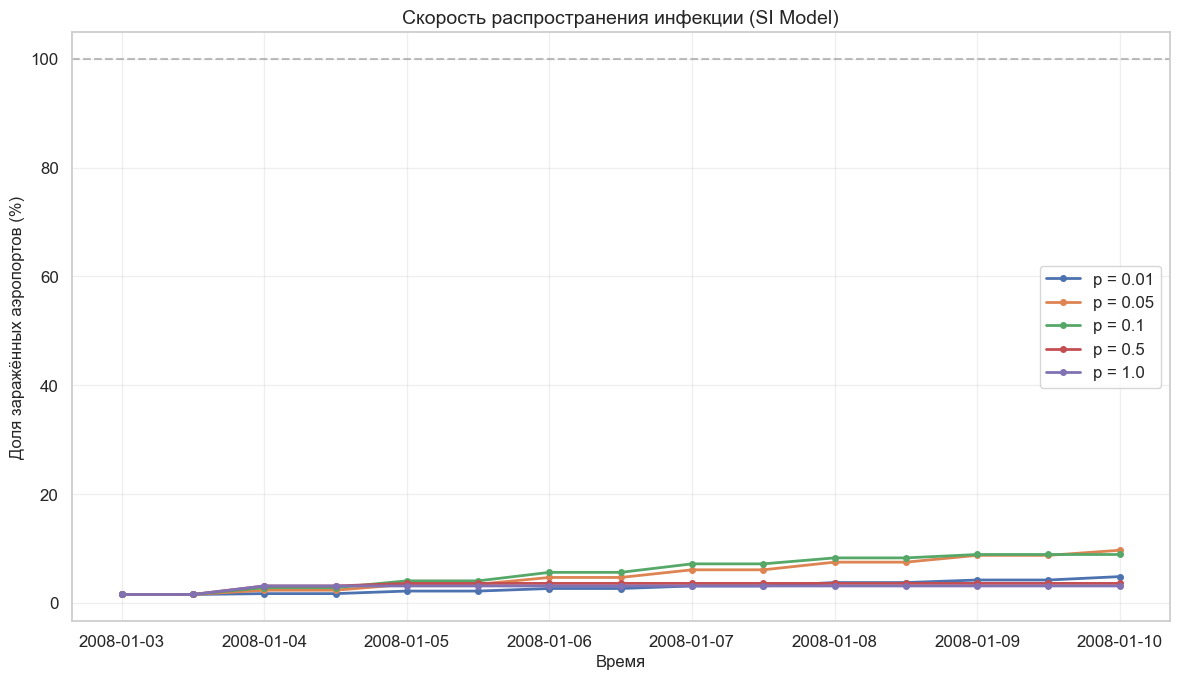

In [15]:
p_values = [0.01, 0.05, 0.1, 0.5, 1.0]
n_sims = 10

# Сетка времени каждые 12 часов
time_steps = pd.date_range(start=start_time_global, end=end_time_global, freq='12h')
results_p = {p: [] for p in p_values}

for p in p_values:
    print(f"Симуляция для p={p}")
    for _ in range(n_sims):
        log = simulate_infection(df, START_AIRPORT, p)
        infected_timestamps = sorted(log.keys())
        counts = []
        for t in time_steps:
            cnt = sum(1 for ts in infected_timestamps if ts <= t)
            counts.append(cnt)
        pct = np.array(counts) / total_airports * 100
        results_p[p].append(pct)

# Усредняем результаты
avg_pct_by_p = {p: np.mean(sim_results, axis=0) for p, sim_results in results_p.items()}

# Визуализация
plt.figure(figsize=(12, 7))
for p in p_values:
    plt.plot(time_steps, avg_pct_by_p[p], marker='o', markersize=4, linewidth=2, label=f'p = {p}')

plt.axhline(100, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Доля заражённых аэропортов (%)', fontsize=12)
plt.title('Скорость распространения инфекции (SI Model)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ графа и предсказание заражения

Граф построен: 64 узлов, 411 рёбер.
Запуск 50 симуляций для графового анализа (p=0.5)
 Аэропортов в анализе: 64


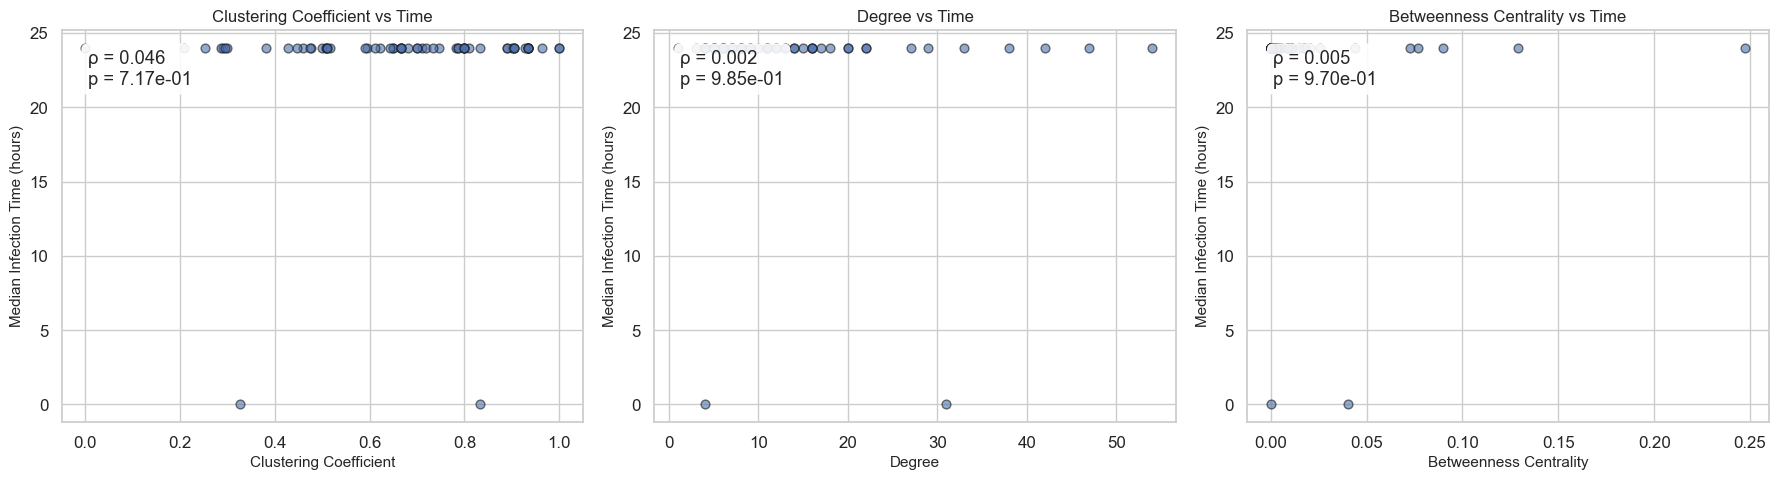


Коэффициенты корреляции Спирмана (ρ):
Clustering Coefficient........ +0.0462
Degree........................ +0.0024
Betweenness Centrality........ +0.0049


In [16]:
# Построение графа
G = nx.Graph()

# Группируем рейсы
flight_pairs = df.groupby(['Origin', 'Dest']).size().reset_index(name='count')
# Делаем ребра ненаправленными
flight_pairs['pair'] = flight_pairs.apply(lambda r: tuple(sorted([r['Origin'], r['Dest']])), axis=1)
pair_counts = flight_pairs.groupby('pair')['count'].sum().reset_index()

total_flights = len(df)

for _, row in pair_counts.iterrows():
    u, v = row['pair']
    weight = row['count'] / total_flights
    G.add_edge(u, v, weight=weight)

# Добавляем изолированные узлы
for ap in all_airports:
    if ap not in G:
        G.add_node(ap)

print(f"Граф построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер.")

# 50 симуляций
n_sims_p3 = 50
p_p3 = 0.5
infection_logs_p3 = []
print(f"Запуск {n_sims_p3} симуляций для графового анализа (p={p_p3})")
# Это может занять время (~5-15 минут в зависимости от CPU)
for _ in range(n_sims_p3):
    infection_logs_p3.append(simulate_infection(df, START_AIRPORT, p_p3))

# Расчет медианного времени заражения
city_median_times = {}

for ap in G.nodes():
    times = []
    for log in infection_logs_p3:
        for t, airports_list in log.items():
            if ap in airports_list:
                times.append(t)
                break
    if times:
        times_ns = [t.value for t in times]
        median_ns = int(np.median(times_ns))
        city_median_times[ap] = pd.Timestamp(median_ns)
    else:
        city_median_times[ap] = np.inf

infected_cities = [ap for ap, t in city_median_times.items() if t != np.inf]
print(f" Аэропортов в анализе: {len(infected_cities)}")

if len(infected_cities) > 0:
    # Метрики графа
    clustering_coeff = nx.clustering(G)
    degree_cent = dict(G.degree())
    betweenness_cent = nx.betweenness_centrality(G)

    # Подготовка данных для графиков
    median_t_hours = [(city_median_times[ap] - start_time_global).total_seconds() / 3600 for ap in infected_cities]
    clust_vals = [clustering_coeff[ap] for ap in infected_cities]
    degree_vals = [degree_cent[ap] for ap in infected_cities]
    betw_vals = [betweenness_cent[ap] for ap in infected_cities]

    # Визуализация и Корреляция
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics_data = [
        ('Clustering Coefficient', clust_vals),
        ('Degree', degree_vals),
        ('Betweenness Centrality', betw_vals)
    ]

    correlations = {}

    for ax, (name, vals) in zip(axes, metrics_data):
        ax.scatter(vals, median_t_hours, alpha=0.6, edgecolor='k', s=40)
        ax.set_xlabel(name, fontsize=11)
        ax.set_ylabel('Median Infection Time (hours)', fontsize=11)
        ax.set_title(f'{name} vs Time', fontsize=12)
        
        corr, p_val = spearmanr(vals, median_t_hours)
        correlations[name] = corr
        
        ax.text(0.05, 0.95, f'ρ = {corr:.3f}\np = {p_val:.2e}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
            
    plt.tight_layout()
    plt.show()

    print("\nКоэффициенты корреляции Спирмана (ρ):")
    for metric, corr in correlations.items():
        print(f"{metric:.<30} {corr:+.4f}")

## Вывод
В данной сети аэропортов (64 узла, 411 ребро) при вероятности заражения p=0.5 топологические характеристики (степень узла, посредническая центральность, коэффициент кластеризации) не оказывают значимого влияния на время заражения. Это может свидетельствовать о том, что:

- Сеть достаточно мала и хорошо связана
- Высокая вероятность заражения (50%) нивелирует влияние топологии
- Инфекция распространяется практически одновременно по всей сети после преодоления начального барьера